# UPPP 135 - Assignment 3

<a target="_blank" href="https://colab.research.google.com/github/knaaptime/uppp135-winter26-assn/blob/main/assignments/assignment3.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

uncomment and run the first cell to install `pandarm` and `geosnap`

In [1]:
# !pip install geosnap pandarm

In [2]:
import pandas as pd
import geopandas as gpd
from fsspec import filesystem

fs = filesystem("https")

ca = gpd.read_parquet("https://github.com/oturns/example_datasets/raw/refs/heads/main/acs/ca_tracts_2021.pq", filesystem=fs)
ca = ca.to_crs(32611)

## Data & Mapping

In [3]:
# riverside
rside = ca[ca.geoid.str.startswith('06065')]

# san diego
sd = ca[ca.geoid.str.startswith('06073')]

# LA
la = ca[ca.geoid.str.startswith('06037')]


<Axes: >

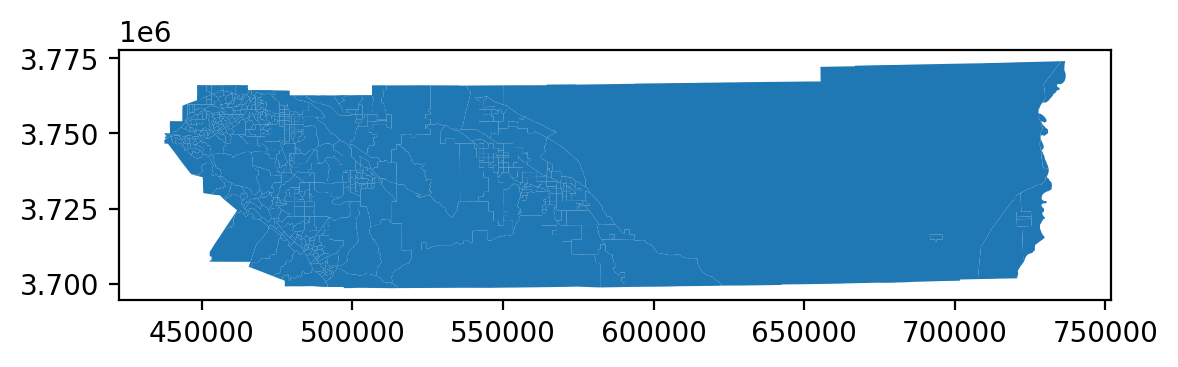

In [4]:
rside.plot()

Create a new variable holding census tracts for Orange County. Hint, the OC FIPS code is '06059'

Create an interactive map of the `rside` data showing the `p_persons_over_60` variable using the `fisherjenks` classification scheme and `7` classes

## Network Distance & Isochrones

In [6]:
oc_subset = oc.head(50)
oc_subset.explore()

In [7]:
import geosnap as gsp
net = gsp.io.get_network_from_gdf(oc_subset)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/knaaptime/Library/CloudStorage/Dropbox/projects/geosnap/geosnap/io/networkio.py:71: UserWarning: GeoDataFrame is stored in coordinate system EPSG:32611 so the pandarm.Network will also be stored in this system
  warn(
/Users/knaaptime/Library/CloudStorage/Dropbox/projects/geosnap/geosnap/io/networkio.py:98: UserWarning: No CRS was passed to geometry input; assuming geographic coordinates
  net = pdna.Network(


Generating contraction hierarchies with 8 threads.
Setting CH node vector of size 20689
Setting CH edge vector of size 57600
Range graph removed 59062 edges of 115200
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%


In [8]:
fullerton_lib = gpd.tools.geocode('fullerton public library, fullerton CA')
fullerton_lib = fullerton_lib.to_crs(32611)

In [9]:
fullerton_lib.explore(marker_kwds={'radius':20}, color='magenta')

In [10]:
iso_1km = gsp.analyze.isochrones_from_gdf(fullerton_lib, network=net, threshold=1000)

In [11]:
iso_1km.explore()

In [12]:
iso_1km.area

origin
0    1.410019e+06
dtype: float64

Create a two-kilometer isochrone around the Fullerton Library, similar to what's been done above

In [13]:
iso_2km = ## your answer here

Create an interactive map of the 2km isochrone. For an bonus point, show the 1km isochrone and 2km isochrones on the same map, with one of them in a different color

use the `area` attribute of the dataframe to find the total area covered by the 2km isochrone. How much larger is it than the 1km? (hint subtract the area from the 1km isochrone from the 2km isochrone)

## Segregation

In [18]:
import segregation as seg

### single-group

In [19]:
oc_hnh = seg.singlegroup.Entropy(oc, group_pop_var='n_hispanic_persons', total_pop_var='n_total_pop')

In [20]:
oc_hnh.statistic

np.float64(0.2255309905381261)

Now calculate an `Entropy` measure for LA, San Diego and Riverside counties. Which county has the highest level of segregation according to this measure?

### Multigroup

In [23]:
groups = ['n_nonhisp_white_persons', 'n_nonhisp_black_persons', 'n_asian_persons', 'n_hispanic_persons']

la_multigroup = seg.multigroup.MultiInfoTheory(la, groups=groups)

la_multigroup.statistic

np.float64(0.29354146052442875)

Compute the multigroup `MultiInfoTheory` index for Riverside and San Diego counties. Which place has the larger index?

### multiscale

In [26]:
# Create a list of distances between 500 and 4000 at 500m intervals
dists = list(range(500,4500, 500))

In [27]:
la_hnh_profile = seg.dynamics.compute_multiscalar_profile(la, segregation_index=seg.singlegroup.Entropy, group_pop_var='n_hispanic_persons', total_pop_var='n_total_pop', distances=dists)

<Axes: xlabel='distance'>

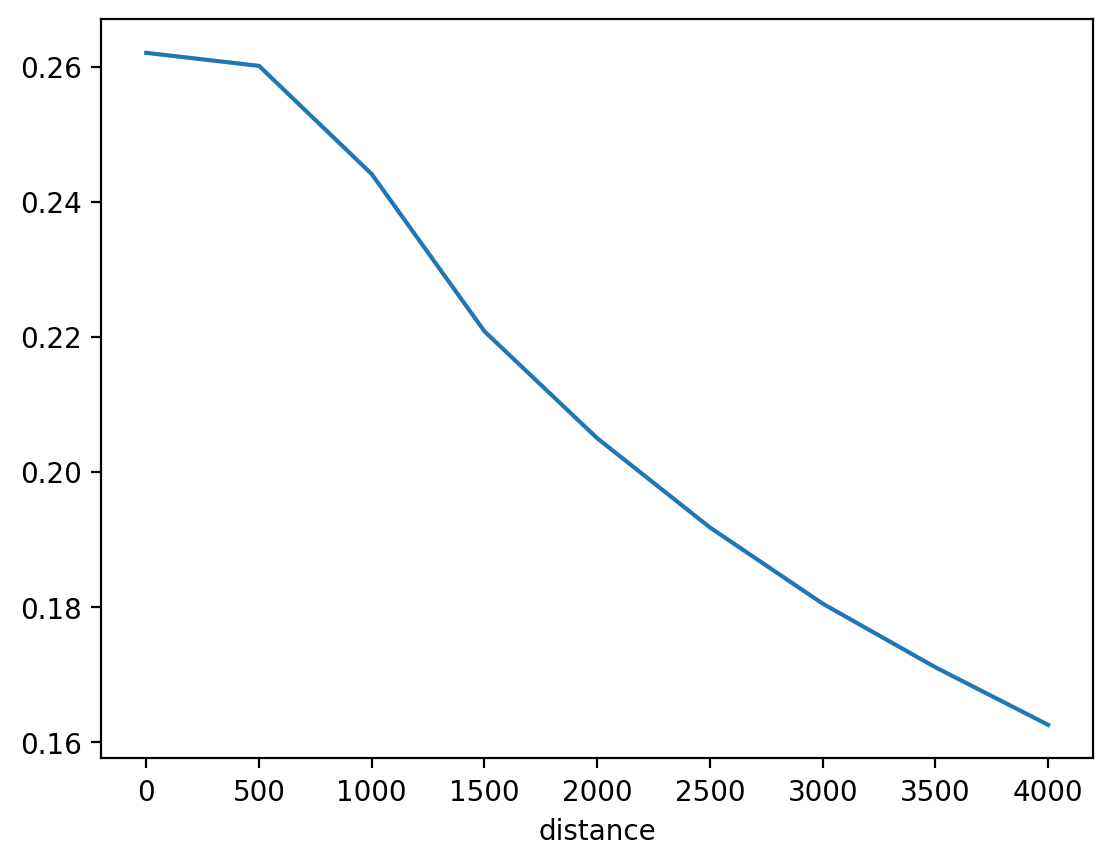

In [28]:
la_hnh_profile.plot()

In words, explain what the segregation profile represents

Compute two segregation profile using the `Entropy` index for the `n_native_persons` variable in san diego and riverside

In [ ]:
sd_native_profile = ## put your answer here

rside_native_profile = ## put your answer here

In [ ]:
sd_native_profile.rename('SD').plot(legend=True)
rside_native_profile.rename('riverside').plot(legend=True)

Around what distance does native segregation in Riverside become larger than San Diego (hint look where the lines cross each other)